# **AI-Based Multi-Label Prediction of Diabetes Complications**

**Deliverable 1 – Problem Definition & Data Foundations**

Dataset: UCI Diabetes 130-US Hospitals (1999–2008)

---
## 1. Data Collection

Load the raw dataset and replace `?` sentinel values with `NaN`. Place `diabetic_data.csv` in the `data/raw/` folder before running (see `data_scripts/data_collection.py` to download automatically).

In [36]:
import pandas as pd
import numpy as np
import os

# ── Resolve path relative to this notebook ────────────────────────────────────
# NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__"))
# DATA_PATH    = os.path.join(NOTEBOOK_DIR, "..", "data", "raw", "diabetic_data.csv")

df = pd.read_csv('../data/diabetic_data.csv')



df.replace("?", np.nan, inplace=True)

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 101,766 rows × 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


---
## 2. Data Cleaning

### 2.1 Missing Value Report

In [37]:
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Percentage of missing values per column:")
print(missing_pct.to_string())


Percentage of missing values per column:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02


### 2.2 Clean Dataset

In [38]:
def clean_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Drop columns with excessive missing values or no clinical value
    df.drop(columns=["encounter_id", "weight", "payer_code", "medical_specialty"],
            inplace=True, errors="ignore")

    # Deduplicate: keep first encounter per patient, then drop ID
    df.drop_duplicates(subset="patient_nbr", keep="first", inplace=True)
    df.drop(columns=["patient_nbr"], inplace=True, errors="ignore")

    # Remove invalid gender rows
    df = df[df["gender"] != "Unknown/Invalid"]

    # Fill remaining missing values
    df["race"]          = df["race"].fillna("Unknown")
    df["diag_1"]        = df["diag_1"].fillna("0")
    df["diag_2"]        = df["diag_2"].fillna("0")
    df["diag_3"]        = df["diag_3"].fillna("0")
    df["max_glu_serum"] = df["max_glu_serum"].fillna("None")
    df["A1Cresult"]     = df["A1Cresult"].fillna("None")

    return df

cleaned_df = clean_dataset(df)
print(f"Shape after cleaning: {cleaned_df.shape[0]:,} rows × {cleaned_df.shape[1]} columns")
print("\nRemaining nulls:")
print(cleaned_df.isnull().sum()[cleaned_df.isnull().sum() > 0])


Shape after cleaning: 71,515 rows × 45 columns

Remaining nulls:
Series([], dtype: int64)


In [39]:
PROCESSED_DIR = os.path.join(NOTEBOOK_DIR, "..", "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)
CLEANED_PATH = os.path.join(PROCESSED_DIR, "diabetic_cleaned.csv")
cleaned_df.to_csv(CLEANED_PATH, index=False)
print(f"Saved → {CLEANED_PATH}")
cleaned_df.head()


Saved → /workspaces/Diabetes-Complication-Risk-Prediction-Model/notebooks/../data/processed/diabetic_cleaned.csv


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


---
## 3. Data Preprocessing

In [40]:
import pickle
from sklearn.preprocessing import StandardScaler

NUMERIC_COLS = [
    "age", "time_in_hospital", "num_lab_procedures", "num_procedures",
    "num_medications", "number_outpatient", "number_emergency",
    "number_inpatient", "number_diagnoses",
]

MEDICATION_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "troglitazone", "tolazamide", "examide",
    "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone",
]


def convert_age(age_range: str) -> float:
    """Convert age bracket '[10-20)' → midpoint 15.0"""
    cleaned = age_range.replace("[","").replace("(","").replace("]","").replace(")","")
    lo, hi  = cleaned.split("-")
    return (int(lo) + int(hi)) / 2


def preprocess(df: pd.DataFrame):
    df = df.copy()

    df["age"]         = df["age"].apply(convert_age)
    df["gender"]      = df["gender"].map({"Male": 1, "Female": 0})
    df["change"]      = df["change"].map({"Ch": 1, "No": 0})
    df["diabetesMed"] = df["diabetesMed"].map({"Yes": 1, "No": 0})
    df["readmitted"]  = df["readmitted"].map({"NO": 0, ">30": 1, "<30": 2}).fillna(0)

    med_map = {"No": 0, "Steady": 1, "Up": 2, "Down": 3}
    for col in MEDICATION_COLS:
        if col in df.columns:
            df[col] = df[col].map(med_map).fillna(0).astype(int)

    df = pd.get_dummies(df, columns=["race", "max_glu_serum", "A1Cresult"], drop_first=False)
    df = df.replace({True: 1, False: 0})

    numeric_present = [c for c in NUMERIC_COLS if c in df.columns]
    scaler = StandardScaler()
    df[numeric_present] = scaler.fit_transform(df[numeric_present])

    return df, scaler, numeric_present


preprocessed_df, scaler, numeric_present = preprocess(cleaned_df)
print(f"Shape after preprocessing: {preprocessed_df.shape}")
preprocessed_df.head()


Shape after preprocessing: (71515, 56)


,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,race_Other,race_Unknown,max_glu_serum_>200,max_glu_serum_>300,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm
0,0,-3.795892,6,25,1,-1.115288,-0.104043,-0.812874,-1.769311,-0.26201,...,0,0,0,0,1,0,0,0,1,0
1,0,-3.170041,1,1,7,-0.437130,0.798122,-0.812874,0.276135,-0.26201,...,0,0,0,0,1,0,0,0,1,0
2,0,-2.544189,1,1,7,-0.776209,-1.607650,2.028300,-0.325467,1.60895,...,0,0,0,0,1,0,0,0,1,0
3,1,-1.918337,1,1,7,-0.776209,0.046318,-0.244639,0.035495,-0.26201,...,0,0,0,0,1,0,0,0,1,0
4,1,-1.292485,1,1,7,-1.115288,0.397160,-0.812874,-0.927069,-0.26201,...,0,0,0,0,1,0,0,0,1,0


In [41]:
PREPROCESSED_PATH = os.path.join(PROCESSED_DIR, "diabetic_preprocessed.csv")
SCALER_PATH       = os.path.join(PROCESSED_DIR, "scaler.pkl")

preprocessed_df.to_csv(PREPROCESSED_PATH, index=False)
with open(SCALER_PATH, "wb") as f:
    pickle.dump({"scaler": scaler, "numeric_cols": numeric_present}, f)

print(f"Saved → {PREPROCESSED_PATH}")
print(f"Saved → {SCALER_PATH}")


Saved → /workspaces/Diabetes-Complication-Risk-Prediction-Model/notebooks/../data/processed/diabetic_preprocessed.csv
Saved → /workspaces/Diabetes-Complication-Risk-Prediction-Model/notebooks/../data/processed/scaler.pkl


---
## 4. Feature Engineering

In [42]:
def safe_float(value):
    try:
        return float(value)
    except (ValueError, TypeError):
        return None


def classify_complications(row) -> pd.Series:
    """
    Derive binary complication labels from ICD-9 codes.
    Ranges:
        Cardiovascular : 390–459
        Kidney Disease : 580–589
        Neuropathy     : 354–357
    """
    diagnoses      = [row["diag_1"], row["diag_2"], row["diag_3"]]
    cardiovascular = kidney = neuropathy = 0

    for diag in diagnoses:
        val = safe_float(diag)
        if val is None:
            continue
        if 390 <= val <= 459:
            cardiovascular = 1
        if 580 <= val <= 589:   # corrected upper bound (was 629)
            kidney = 1
        if 354 <= val <= 357:   # corrected to full neuropathy range (was just 357)
            neuropathy = 1

    return pd.Series([cardiovascular, kidney, neuropathy])


fe_df = cleaned_df.copy()   # use cleaned (not scaled) so diag cols are intact

fe_df[["cardiovascular_complication",
       "kidney_complication",
       "neuropathy_complication"]] = fe_df.apply(classify_complications, axis=1)

# Longitudinal feature
fe_df["total_prior_visits"] = (
    fe_df["number_outpatient"] + fe_df["number_emergency"] + fe_df["number_inpatient"]
)

labels = ["cardiovascular_complication", "kidney_complication", "neuropathy_complication"]
print("Complication label counts:")
print(fe_df[labels].sum().rename("Positive Cases"))
print()
print("Prevalence (%):")
print((fe_df[labels].mean() * 100).round(2).rename("Prevalence %"))


Complication label counts:
cardiovascular_complication    41244
kidney_complication             4740
neuropathy_complication          439
Name: Positive Cases, dtype: int64

Prevalence (%):
cardiovascular_complication    57.67
kidney_complication             6.63
neuropathy_complication         0.61
Name: Prevalence %, dtype: float64


In [43]:
# Build final dataset: merge preprocessed features with new labels
final_df = preprocessed_df.copy()
final_df["total_prior_visits"]        = fe_df["total_prior_visits"].values
final_df["cardiovascular_complication"] = fe_df["cardiovascular_complication"].values
final_df["kidney_complication"]        = fe_df["kidney_complication"].values
final_df["neuropathy_complication"]    = fe_df["neuropathy_complication"].values

FINAL_PATH = os.path.join(PROCESSED_DIR, "diabetic_final.csv")
final_df.to_csv(FINAL_PATH, index=False)
print(f"Final dataset saved → {FINAL_PATH}  ({final_df.shape[0]:,} × {final_df.shape[1]})")


Final dataset saved → /workspaces/Diabetes-Complication-Risk-Prediction-Model/notebooks/../data/processed/diabetic_final.csv  (71,515 × 60)


---
## 5. Exploratory Data Analysis

### Import Libraries

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"]  = 11
sns.set_theme(style="whitegrid", palette="muted")

FIGURES_DIR = os.path.join(NOTEBOOK_DIR, "..", "report", "deliverable_1", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"Figures will be saved to: {os.path.abspath(FIGURES_DIR)}")


Figures will be saved to: /workspaces/Diabetes-Complication-Risk-Prediction-Model/report/deliverable_1/figures


### Dataset Overview

In [45]:
print(f"Final dataset shape: {final_df.shape[0]:,} rows × {final_df.shape[1]} columns")
final_df.describe().round(3)


Final dataset shape: 71,515 rows × 60 columns


,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,total_prior_visits,cardiovascular_complication,kidney_complication,neuropathy_complication
count,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,...,71515.0,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000,71515.000
mean,0.468,0.000,2.100,3.593,5.657,-0.000,-0.000,0.000,0.000,0.000,...,0.0,0.000,0.000,0.448,0.760,0.487,0.561,0.577,0.066,0.006
std,0.499,1.000,1.508,5.269,4.163,1.000,1.000,1.000,1.000,1.000,...,0.0,0.005,0.004,0.497,0.427,0.653,1.431,0.494,0.249,0.078
min,0.000,-3.796,1.000,1.000,1.000,-1.115,-2.109,-0.813,-1.769,-0.262,...,0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,-0.667,1.000,1.000,1.000,-0.776,-0.605,-0.813,-0.686,-0.262,...,0.0,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
50%,0.000,-0.041,1.000,1.000,7.000,-0.437,0.046,-0.245,-0.205,-0.262,...,0.0,0.000,0.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
75%,1.000,0.585,3.000,3.000,7.000,0.580,0.698,0.324,0.517,-0.262,...,0.0,0.000,0.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000
max,1.000,1.837,8.000,28.000,25.000,3.293,4.457,2.597,7.856,39.028,...,0.0,1.000,1.000,1.000,1.000,2.000,49.000,1.000,1.000,1.000


### 5.1 Class Distribution

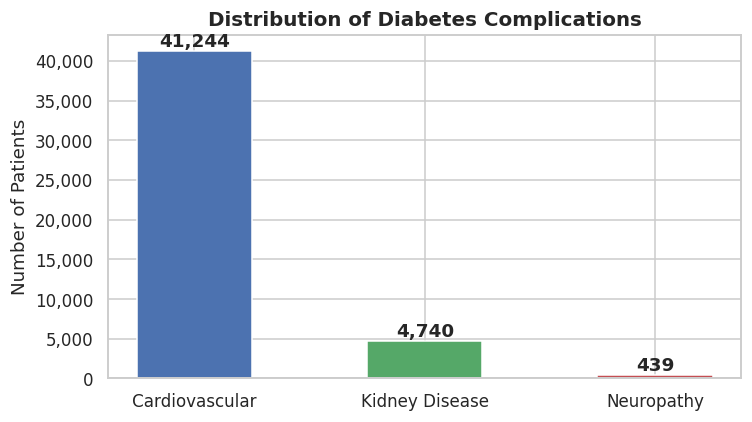

In [46]:
COLORS      = ["#4C72B0", "#55A868", "#C44E52"]
label_names = ["Cardiovascular", "Kidney Disease", "Neuropathy"]

fig, ax = plt.subplots(figsize=(7, 4))
counts = final_df[labels].sum()
bars   = ax.bar(label_names, counts.values, color=COLORS, width=0.5, edgecolor="white")

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{val:,}", ha="center", va="bottom", fontweight="bold")

ax.set_title("Distribution of Diabetes Complications", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Patients")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_distribution.png"), dpi=120)
plt.show()


### 5.2 Age Distribution

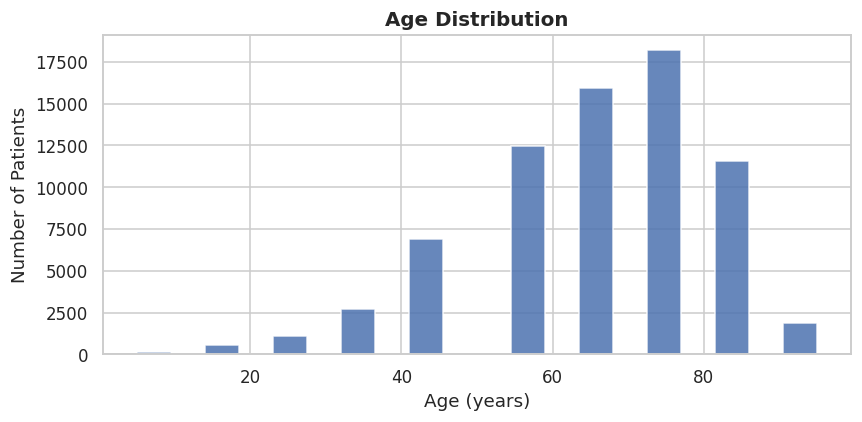

In [47]:
# Inverse-transform to recover original age values for readable axis
age_idx      = numeric_present.index("age") if "age" in numeric_present else None
age_original = None

if age_idx is not None:
    age_scaled   = final_df[numeric_present].values
    age_original = scaler.inverse_transform(age_scaled)[:, age_idx]

fig, ax = plt.subplots(figsize=(8, 4))
if age_original is not None:
    ax.hist(age_original, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_xlabel("Age (years)")
else:
    ax.hist(final_df["age"], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_xlabel("Age (scaled)")

ax.set_ylabel("Number of Patients")
ax.set_title("Age Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "age_distribution.png"), dpi=120)
plt.show()


### 5.3 Feature Correlation Heatmap

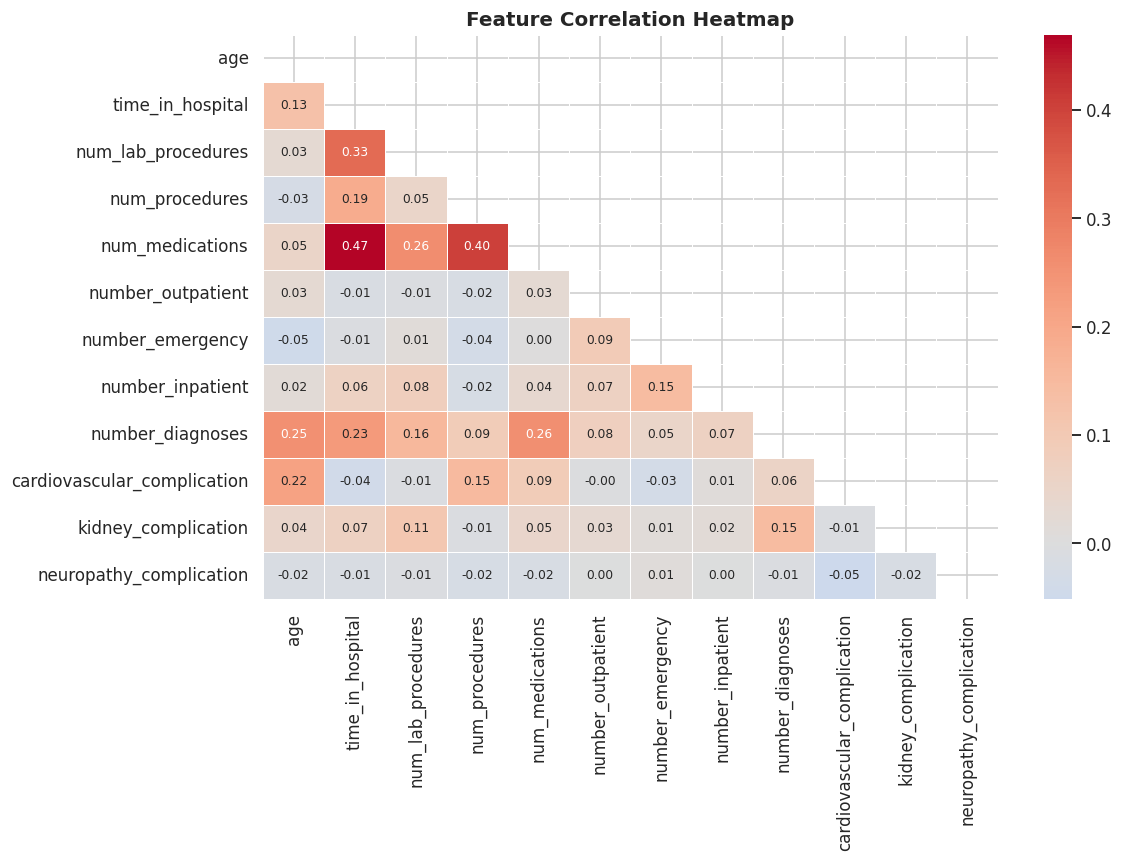

In [48]:
# Use a representative subset of features to keep the heatmap readable
heatmap_cols = numeric_present + labels
corr = final_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "feature_correlation.png"), dpi=120)
plt.show()


### 5.4 Average Hospital Visits

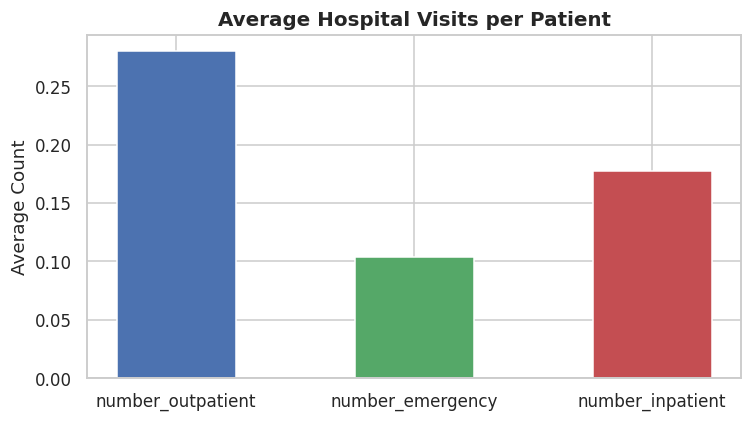

In [49]:
# Inverse-transform visit columns to recover original counts
visit_col_names = ["number_outpatient", "number_emergency", "number_inpatient"]
visit_cols_idx  = [numeric_present.index(c) for c in visit_col_names if c in numeric_present]

all_scaled    = final_df[numeric_present].values
all_original  = scaler.inverse_transform(all_scaled)

visit_means   = {c: all_original[:, numeric_present.index(c)].mean()
                 for c in visit_col_names if c in numeric_present}

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(list(visit_means.keys()), list(visit_means.values()),
       color=COLORS, edgecolor="white", width=0.5)
ax.set_title("Average Hospital Visits per Patient", fontsize=13, fontweight="bold")
ax.set_ylabel("Average Count")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "average_visits.png"), dpi=120)
plt.show()


### 5.5 Insulin Usage

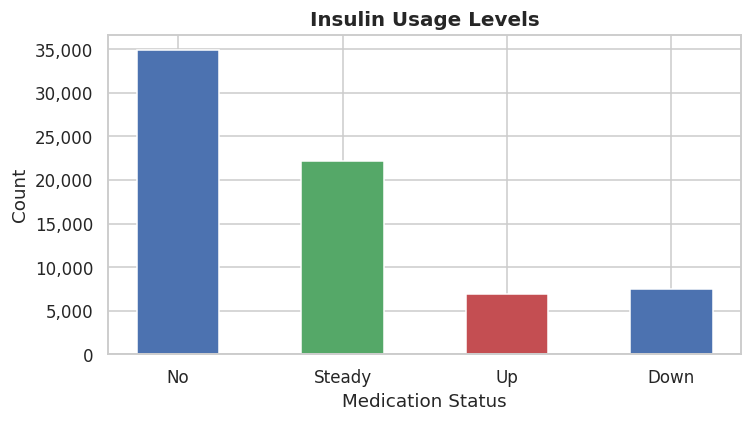

In [50]:
# Map numeric codes back to labels for a readable bar chart
insulin_labels = {0: "No", 1: "Steady", 2: "Up", 3: "Down"}
insulin_counts = final_df["insulin"].value_counts().sort_index()
insulin_counts.index = [insulin_labels.get(i, str(i)) for i in insulin_counts.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(insulin_counts.index, insulin_counts.values,
       color=COLORS[:len(insulin_counts)], edgecolor="white", width=0.5)
ax.set_title("Insulin Usage Levels", fontsize=13, fontweight="bold")
ax.set_xlabel("Medication Status")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "insulin_usage.png"), dpi=120)
plt.show()


### 5.6 Complication Co-occurrence Heatmap

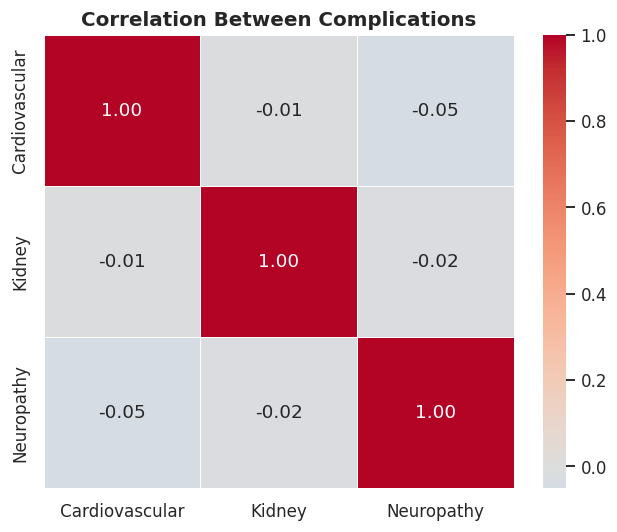

In [51]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    final_df[labels].corr(),
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, ax=ax,
    xticklabels=["Cardiovascular", "Kidney", "Neuropathy"],
    yticklabels=["Cardiovascular", "Kidney", "Neuropathy"],
)
ax.set_title("Correlation Between Complications", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "complication_correlation.png"), dpi=120)
plt.show()


---
## Summary

| Item | Value |
|---|---|
| Unique patients | ≈ 70,000 |
| Features after preprocessing | see `final_df.shape` |
| Labels | `cardiovascular_complication`, `kidney_complication`, `neuropathy_complication` |
| Scaler saved | `data/processed/scaler.pkl` |
| Final dataset | `data/processed/diabetic_final.csv` |

**Next steps (Deliverable 2):** train/test split → multi-label classifier (Random Forest, XGBoost, MLP) → evaluate with F1-Micro, F1-Macro, Recall.